In [1]:
import pandas as pd
import matplotlib.pyplot as plt


## Data Cleaning

### 1.Load the News Dataset

In [2]:
news_df = pd.read_csv(
    r"C:\Users\dhama\Desktop\MarketPulse_NLP\sp500_headlines_2008_2024.csv"
)

print(news_df.shape)
news_df.head()

(19127, 3)


,Title,Date,CP
0,"JPMorgan Predicts 2008 Will Be ""Nothing But Net""",2008-01-02,1447.16
1,Dow Tallies Biggest First-session-of-year Poin...,2008-01-02,1447.16
2,2008 predictions for the S&P 500,2008-01-02,1447.16
3,"U.S. Stocks Higher After Economic Data, Monsan...",2008-01-03,1447.16
4,U.S. Stocks Climb As Hopes Increase For More F...,2008-01-07,1416.18


### 2.Basic Checks

In [3]:
print(news_df.info())
print(news_df.columns)
print(news_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19127 entries, 0 to 19126
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Title   19127 non-null  object 
 1   Date    19127 non-null  object 
 2   CP      19127 non-null  float64
dtypes: float64(1), object(2)
memory usage: 448.4+ KB
None
Index(['Title', 'Date', 'CP'], dtype='object')
Title    0
Date     0
CP       0
dtype: int64


### 3.Keep Only Necessary Columns

In [4]:
news_df = news_df[["Date", "Title"]]

### 4.Check Date Range

In [5]:
print("Start Date :", news_df["Date"].min())
print("End Date   :", news_df["Date"].max())

Start Date : 2008-01-02
End Date   : 2024-03-04


### 5.Convert Date column to Datetime Object

In [6]:
news_df["Date"] = pd.to_datetime(news_df["Date"])

### 6.Filter Data for Year 2020-2024

In [7]:
news_df = news_df[
    (news_df["Date"] >= "2020-01-01")
    &
    (news_df["Date"] <= "2024-12-31")
]

In [8]:
print(news_df.shape)

(10734, 2)


### 7.Check if news for our Stock Data Exists

In [9]:
stocks = {
    "AAPL": "Apple",
    "MSFT": "Microsoft",
    "NVDA": "Nvidia",
    "TSLA": "Tesla",
    "JPM": "JPMorgan",
    "GS": "Goldman Sachs",
    "XOM": "Exxon",
    "CVX": "Chevron",
    "PFE": "Pfizer",
    "JNJ": "Johnson"
}
for ticker, company in stocks.items():

    count = news_df["Title"].str.contains(
        company,
        case=False,
        na=False
    ).sum()

    print(f"{ticker} ({company}) : {count}")

AAPL (Apple) : 116
MSFT (Microsoft) : 32
NVDA (Nvidia) : 107
TSLA (Tesla) : 237
JPM (JPMorgan) : 45
GS (Goldman Sachs) : 58
XOM (Exxon) : 18
CVX (Chevron) : 5
PFE (Pfizer) : 8
JNJ (Johnson) : 2


## Feature Engineering

### 1.Date Features

In [10]:
news_df["Year"] = news_df["Date"].dt.year

news_df["Month"] = news_df["Date"].dt.month

news_df["Day"] = news_df["Date"].dt.day

## EDA

### 1.Articles Per Year

Year
2020    1519
2021    1303
2022    2319
2023    4760
2024     833
Name: count, dtype: int64


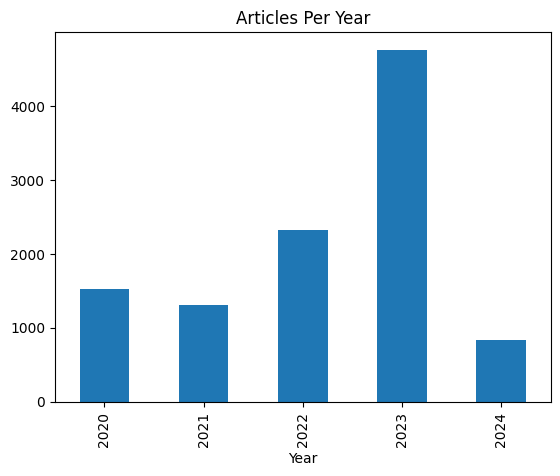

In [11]:
print(
    news_df["Year"]
    .value_counts()
    .sort_index()
)
news_df["Year"]\
       .value_counts()\
       .sort_index()\
       .plot(kind="bar")

plt.title("Articles Per Year")

plt.show()

### 2.Headline Length Feature

In [12]:
news_df["Headline_Length"] = (
    news_df["Title"]
    .str.len()
)

In [13]:
news_df["Headline_Length"].describe()

count    10734.000000
mean        65.811999
std         19.966007
min          8.000000
25%         53.000000
50%         64.000000
75%         78.000000
max        172.000000
Name: Headline_Length, dtype: float64

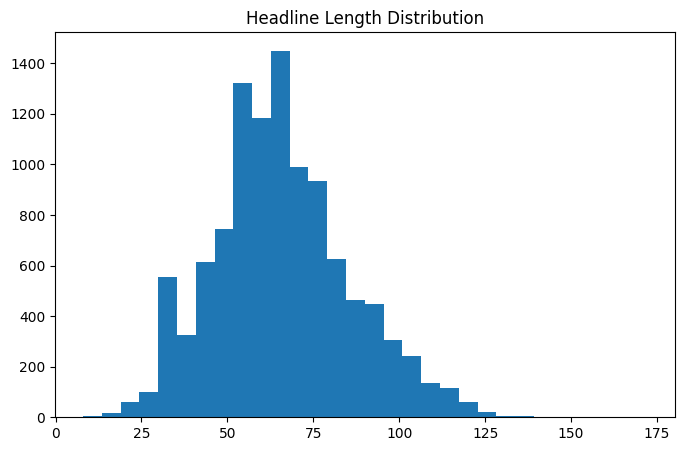

In [14]:
plt.figure(figsize=(8,5))

plt.hist(
    news_df["Headline_Length"],
    bins=30
)

plt.title("Headline Length Distribution")

plt.show()

## NLP

### 1.Text Cleaning

In [15]:
import re
def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r"http\S+",
        "",
        text
    )

    text = re.sub(
        r"[^a-zA-Z\s]",
        "",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()
news_df["clean_text"] = (
    news_df["Title"]
    .apply(clean_text)
)

### 2.Check Cleaned Text

In [16]:
news_df[
    ["Title","clean_text"]
].head()

,Title,clean_text
8393,"'First five days' indicator, which has a solid...",first five days indicator which has a solid tr...
8394,"Stock Market News for Jan 2, 2020",stock market news for jan
8395,SP Funds' Sharia-Compliant ETFs Hit the Market,sp funds shariacompliant etfs hit the market
8396,Irrational exuberance? Why last year’s stellar...,irrational exuberance why last years stellar r...
8397,Is Google's P/E Ratio Too High Or Too Low?,is googles pe ratio too high or too low


### 3.Install VADER

In [17]:
! pip install vaderSentiment


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 4.Sentiment Analysis

In [18]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

### Sentiment Scores

In [19]:
news_df["sentiment_score"] = (
    news_df["clean_text"]
    .apply(
        lambda x:
        analyzer.polarity_scores(x)["compound"]
    )
)

### 5.Sentiment Labels

In [20]:
def get_label(score):

    if score > 0.05:
        return "Positive"

    elif score < -0.05:
        return "Negative"

    else:
        return "Neutral"

In [21]:
news_df["sentiment_label"] = (
    news_df["sentiment_score"]
    .apply(get_label)
)

In [22]:
news_df[
    [
        "Title",
        "sentiment_score",
        "sentiment_label"
    ]
].head(20)

,Title,sentiment_score,sentiment_label
8393,"'First five days' indicator, which has a solid...",0.5423,Positive
8394,"Stock Market News for Jan 2, 2020",0.0000,Neutral
8395,SP Funds' Sharia-Compliant ETFs Hit the Market,0.0000,Neutral
8396,Irrational exuberance? Why last year’s stellar...,-0.5994,Negative
8397,Is Google's P/E Ratio Too High Or Too Low?,-0.2732,Negative
8398,This Hedge Fund Won't Take Management Fees,0.0000,Neutral
8399,Here's How Much Investing $100 In Sears Back I...,0.2263,Positive
8400,Top 5 Best-Performing Stocks of the Past Decad...,0.2023,Positive
8401,Using ETF clones to save on fees,0.4939,Positive
8402,Jim Cramer breaks down the top 2019 S&P 500 pe...,0.2023,Positive


### 6.Sentiment Distribution

In [23]:
print(
    news_df["sentiment_label"]
    .value_counts()
)

sentiment_label
Neutral     5008
Positive    3228
Negative    2498
Name: count, dtype: int64


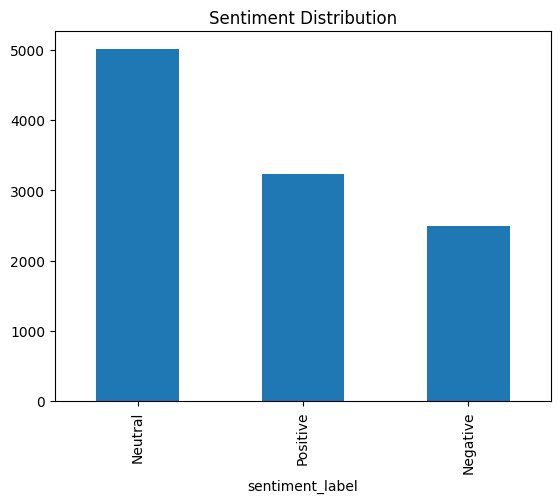

In [24]:
news_df["sentiment_label"]\
       .value_counts()\
       .plot(kind="bar")

plt.title("Sentiment Distribution")

plt.show()

### 7.Daily Sentiment Aggregation

In [25]:
daily_sentiment = (
    news_df
    .groupby("Date")
    ["sentiment_score"]
    .mean()
    .reset_index()
)
daily_sentiment.head()

,Date,sentiment_score
0,2020-01-02,-0.066060
1,2020-01-03,0.100800
2,2020-01-06,0.070340
3,2020-01-07,0.006975
4,2020-01-08,0.045533


### 8.Save the Daily Sentiment Dataset and Full Processed News Dataset

In [26]:
daily_sentiment.to_csv(
    r"C:\Users\dhama\Desktop\MarketPulse NLP\daily_sentiment.csv",
    index=False
)

In [27]:
news_df.to_csv(
    r"C:\Users\dhama\Desktop\MarketPulse NLP\processed_news.csv",
    index=False
)